### Astrostatistic Lecture 17

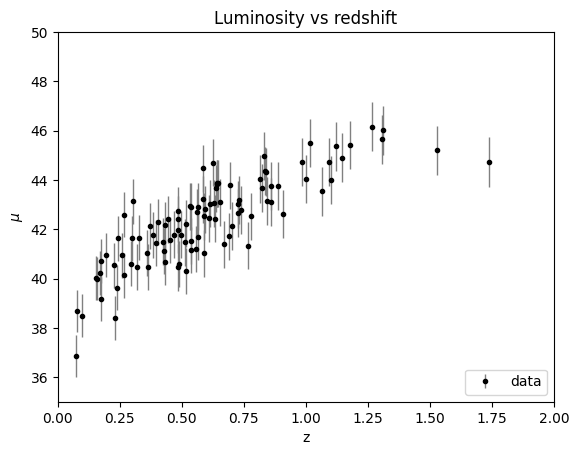

In [33]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
import numpy as np
from tqdm import tqdm
from scipy import stats

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50);

39.56505554722625 [4.64711848]


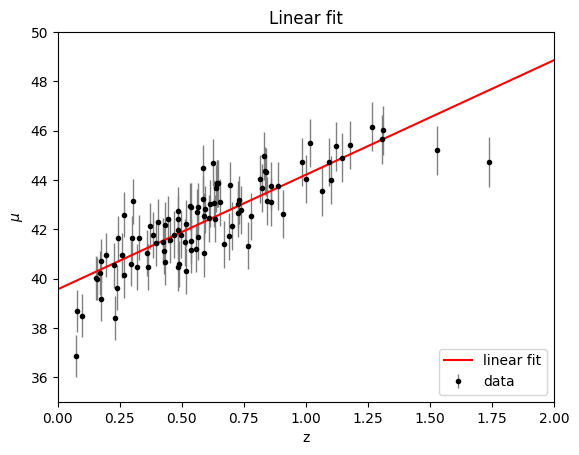

In [34]:
#first we try a linear regression
z_sample=z_sample.reshape(-1,1)

lin_reg = LinearRegression()
lin_reg.fit(z_sample, mu_sample, sample_weight = 1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)

test_z = np.linspace(0,2,100)
test_mu = theta0 + theta1*test_z

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(test_z, test_mu, 'r', label='linear fit')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Linear fit")
plt.xlim(0,2)
plt.ylim(35,50);

polynomial coefficients for 3 degrees: [38.49130243  8.23905057 -2.20391808 -0.15168104]
polynomial coefficients for 4 degrees: [ 37.0543994   20.74217865 -32.83020744  27.30599762  -7.98337391]
polynomial coefficients for 5 degrees: [ 36.18760445  31.00142053 -69.82397489  82.84185044 -44.24104125
   8.47059008]
polynomial coefficients for 6 degrees: [  35.52810145   41.0777603  -119.2923833   190.65950213 -159.23341791
   67.07109508  -11.37900289]
polynomial coefficients for 7 degrees: [   33.0388866     88.36455436  -419.10465978  1070.05460078
 -1505.50746677  1174.27289713  -473.67088511    76.75032208]
polynomial coefficients for 8 degrees: [  33.50565858   77.89342066 -337.63347915  765.41612513 -882.60407243
  442.01979986   18.73687923  -98.85713122   25.70456796]
polynomial coefficients for 9 degrees: [   35.26610351    32.52717374    84.29772047 -1185.19631637
  4221.82035326 -7581.90261683  7725.37965887 -4516.73127681
  1411.30781055  -182.62797456]


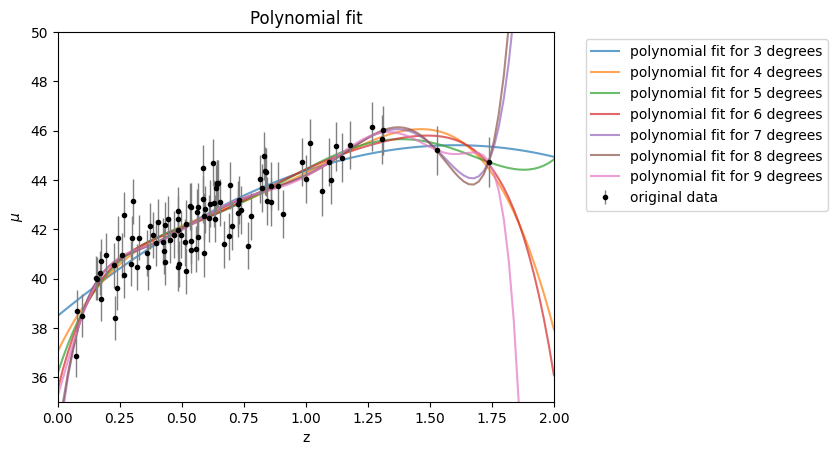

I bet on the 3rd degree


In [ ]:
#polynomial fit 
z_sample=z_sample.reshape(-1,1)
for deg in range(3,10):

    pol_reg = PolynomialRegression(degree=deg)
    pol_reg.fit(z_sample, mu_sample)
    
    print(f'polynomial coefficients for {deg} degrees: {pol_reg.coef_}')
    
    test_z = np.linspace(0,2,100)
    test_mu = pol_reg.predict(test_z.reshape(-1,1))
    
    
    plt.plot(test_z, test_mu, label=f'polynomial fit for {deg} degrees', alpha=0.7)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='original data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Polynomial fit")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()
print('I bet on the 3rd degree or maybe a 4th degree')

In [ ]:
from sklearn.model_selection import train_test_split

#now we can make a cross validation of the polynomial fit
train=[]
test=[]

X_train, X_test, y_train, y_test = train_test_split(z_sample, mu_sample, test_size=0.2, random_state=deg)    #split the sample

for deg in range(3,10):
    print(f'\nPolynomial of degree: {deg}')
    pol_reg = PolynomialRegression(degree=deg)
    pol_reg.fit(X_train, y_train)

    y_pred = pol_reg.predict(X_test)
    train_Err = np.sqrt(np.sum((pol_reg.predict(X_train) - y_train) ** 2)/ len(y_train))
    train.append(train_Err)
    print(f'Train error: {train_Err}')

    test_err = np.sqrt(np.sum((y_pred - y_test) ** 2)/ len(y_pred))
    test.append(test_err)
    print(f'Test error: {test_err}')
    


Polynomial of degree: 3
Train error: 0.9044731315332778
Test error: 0.9201552727141209

Polynomial of degree: 4
Train error: 0.8591086259059652
Test error: 0.9368564846561742

Polynomial of degree: 5
Train error: 0.8508728178102357
Test error: 0.9372927601289135

Polynomial of degree: 6
Train error: 0.8507945325305716
Test error: 0.9341884383793941

Polynomial of degree: 7
Train error: 0.8432291412299725
Test error: 0.8983439494662309

Polynomial of degree: 8
Train error: 0.8427491528917704
Test error: 0.9005118832788516

Polynomial of degree: 9
Train error: 0.8403679002740508
Test error: 0.9087847425471496
